### Simulating a single electrode for a single participant
Simulating an electrode for a single participant when the signal is made up of:
- Aperiodic noise only
- Aperiodic and periodic noise

#### Imports

In [1]:
# Imports required for functionality 
import numpy as np
import matplotlib.pyplot as plt

from dissertation_simulations.params import electrode_sim_params_ap
from dissertation_simulations.params import electrode_sim_params_full
from dissertation_simulations.params import electrode_times
from dissertation_simulations.params import welch_params
from dissertation_simulations.params import spectral_model_params
from dissertation_simulations.params import freq_range

from neurodsp.sim import sim_oscillation, sim_combined, sim_powerlaw
from neurodsp.plts import plot_time_series
from neurodsp.spectral import compute_spectrum_welch

from specparam import SpectralModel
from specparam.plts import plot_spectra

#### Simulate EEG-like signal for a single electrode (aperiodic noise only)

The following code achieves the following:
1. Creates an electrode signal that simulates the aperiodic noise only
2. Plots a time series of this signal
3. Computes and plots the power spectra of this signal
4. Fits the spectral model of this signal 

##### Data Simulation setup for electrode signal (aperiodic)

In [2]:
params = electrode_sim_params_ap # Params dict that contains simulation setting for aperiodic electrode signal

n_seconds = params["n_seconds"]
fs = params["s_rate"]
exponent = -1.5
high_pass_filter = params["high_pass_filter"]
low_pass_filter = params["low_pass_filter"]

times = electrode_times(params) # Created time vector for electrode signal

##### Simulating aperiodic electrode signal 
The aperiodic simulated signal is created using `sim_powerlaw`, with the following parameters:
1. `n_seconds` - length of data segment
2. `fs` - sampling rate in Hz
3. `exponent` - the steepness of the 1/f-like decay
4. `f_range` - a high-pass filter is utilised to filter out frequencies below this value 

In [3]:
# Simulating aperiodic electrode signal 
electrode_signal_ap = sim_powerlaw (n_seconds, fs, exponent = exponent, f_range = [high_pass_filter, low_pass_filter])

##### Plotting the time series of the aperiodic Cz signal 
The simulated signal is then plotted as a time series using the `plot_time_series` function. Two parameters are required for this to run: 
1. `times` - this generates a time vector for signal processing
2. `electrode_signal_ap` - the simulated signal

In [8]:
# Plot time series of aperiodic Cz signal 
plot_time_series(times, electrode_signal_ap)

plt.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures\AperiodicTimeSeriesExample.png",
    dpi=300,
    bbox_inches="tight")

plt.close()

##### Compute and plot the Power Spectral Density (PSD)
The PSD is computed via the function `compute_spectrum_welch` with the following parameters:
1. `electrode_signal_ap` - the simulated signal
2. `fs` - the sampling rate
3. `welch_params` contains the following:
    1. `nperseg` - represents the number of samples per segment. Setting this to the sampling rate means that each segment is 1 second long. This should result in a smoother spectrum
    2. `noverlap` - represents the number of samples that overlap between consecutive segments. Setting this to `fs//2` means that there is a 50% overlap.

The PSD is plotted using `plot_spectra`, which plots the PSD in the frequency domain.

In [7]:
# Plot the simulated data, in the frequency domain
fig, ax = plt.subplots()

welch_dict = welch_params(params)
freqs, powers = compute_spectrum_welch(electrode_signal_ap, fs, **welch_dict)
plot_spectra(freqs, powers, log_powers=True, ax=ax)

ax.set_xlim(-1, 55)
ax.set_ylim(-4, 0)

plt.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures\AperiodicPSDExample.png",
    dpi=300,
    bbox_inches="tight")

plt.close()

##### Plotting the Spectral Model 
The `SpectralModel` is initialised with the following parameters:
1. `spectral_model_params` which contains:
    1. `min_peak_height` - minimum height threshold that a peak must reach for peak detection
    2. `verbose` - switches off warnings for the model

`freq_range` specifies the frequencies at which the model should be plotted between

`.fit` and `.plot` fit and plot the Spectral Model in turn

In [6]:
# Initialise Spectral Model
fm = SpectralModel(**spectral_model_params)

# Set frequency range
freq_range = freq_range

# Fitting, plotting and reporting spectral models for each signal
fm.fit(freqs, powers, freq_range)
fm.plot(title = "Single Electrode (aperiodic)")

plt.savefig(
    r"C:\Users\chloe\DissertationSimulations\Figures\AperiodicSpectralModelExample.png",
    dpi=300,
    bbox_inches="tight")

plt.close()

#### Simulate EEG-like signal for single electrode (aperiodic and periodic)

The following code achieves the following:
1. Creates an electrode signal that simulates the aperiodic and periodic noise
2. Plots a time series of this signal
3. Computes and plots the power spectra of this signal
4. Fits the spectral model of this signal 

##### Data Simulation setup for electrode signal (aperiodic and periodic)

In [7]:
params = electrode_sim_params_full # Params dict that contains simulation setting for full electrode signal

n_seconds = params["n_seconds"]
fs = params["s_rate"]
exponent = params["exponent"]
high_pass_filter = params["high_pass_filter"]
low_pass_filter = params["low_pass_filter"]
freq = params ["oscillation"]

electrode_seed(params) # Sets random seed for consistency
times = electrode_times(params) # Created time vector for electrode signal

##### Simulating single electrode signal 
The simulated signal is created using a combination of `sim_powerlaw` and `sim_oscillation`, which are assigned to the variable `components`. 

`sim_powerlaw` contains the following parameters:
1. `exponent` - the steepness of the 1/f-like decay
2. `f_range` - a high-pass filter is utilised to filter out frequencies below this value

`sim_oscillation` contains the following parameter:
1. `freq` - the frequency of the periodic oscillation in Hz

These are combined using the `sim_combined` function with the additional parameters of:
1. `n_seconds` - length of data segment
2. `fs` - sampling rate in Hz
3. `components` - the signals that are being combined

In [8]:
components = {
    'sim_powerlaw': {'exponent': exponent, 'f_range': [high_pass_filter, low_pass_filter]},
    'sim_oscillation': {'freq': freq}
}

electrode_signal_full = sim_combined(n_seconds, fs, components=components)                

##### Plotting the time series of the electrode signal 
The simulated signal is then plotted as a time series using the `plot_time_series` function. Two parameters are required for this to run: 
1. `times` - this generates a time vector for signal processing
2. `electrode_signal_full` - the simulated signal

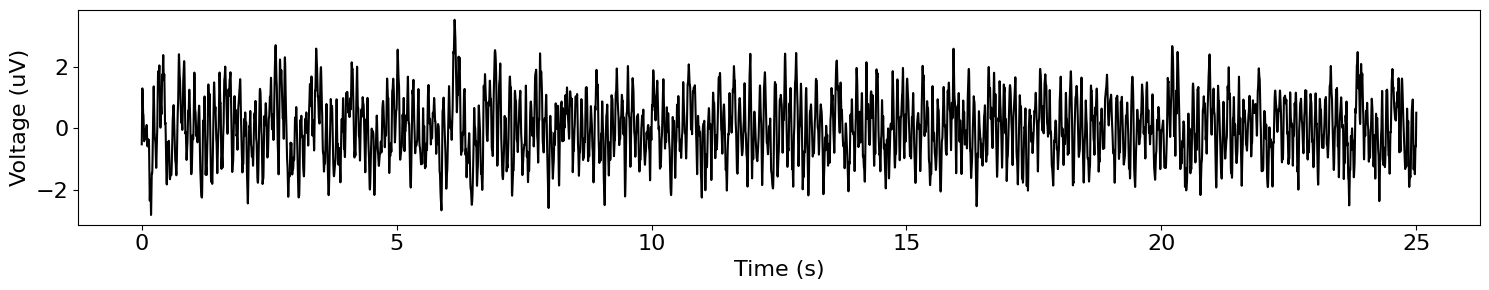

In [9]:
# Plot time series
plot_time_series(times, electrode_signal_full)

##### Compute and plot the Power Spectral Density (PSD)
The PSD is computed via the function `compute_spectrum_welch` with the following parameters:
1. `electrode_signal_full` - the simulated signal
2. `fs` - the sampling rate
3. `welch_params` contains the following:
    1. `nperseg` - represents the number of samples per segment. Setting this to the sampling rate means that each segment is 1 second long. This should result in a smoother spectrum
    2. `noverlap` - represents the number of samples that overlap between consecutive segments. Setting this to `fs//2` means that there is a 50% overlap.

The PSD is plotted using `plot_spectra`, which plots the PSD in the frequency domain.

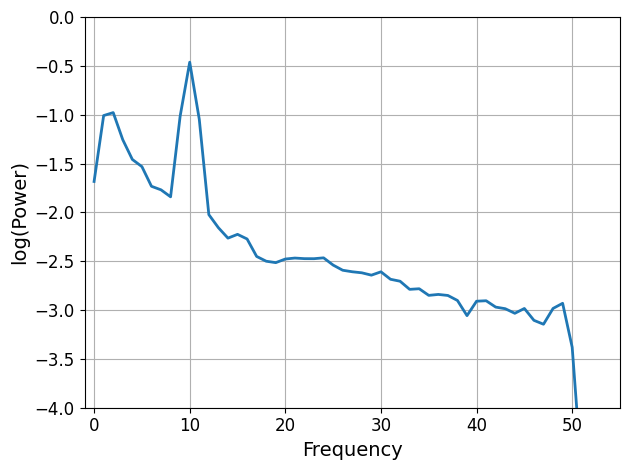

In [10]:
# Plot the simulated data, in the frequency domain
fig, ax = plt.subplots()

welch_dict = welch_params(params)
freqs, powers = compute_spectrum_welch(electrode_signal_full, fs, **welch_dict)
plot_spectra(freqs, powers, log_powers=True, ax=ax)

ax.set_xlim(-1, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plotting the Spectral Model 
The `SpectralModel` is initialised with the following parameters:
1. `spectral_model_params` which contains:
    1. `min_peak_height` - minimum height threshold that a peak must reach for peak detection
    2. `verbose` - switches off warnings for the model

`freq_range` specifies the frequencies at which the model should be plotted between

`.fit` and `.plot` fit and plot the Spectral Model in turn

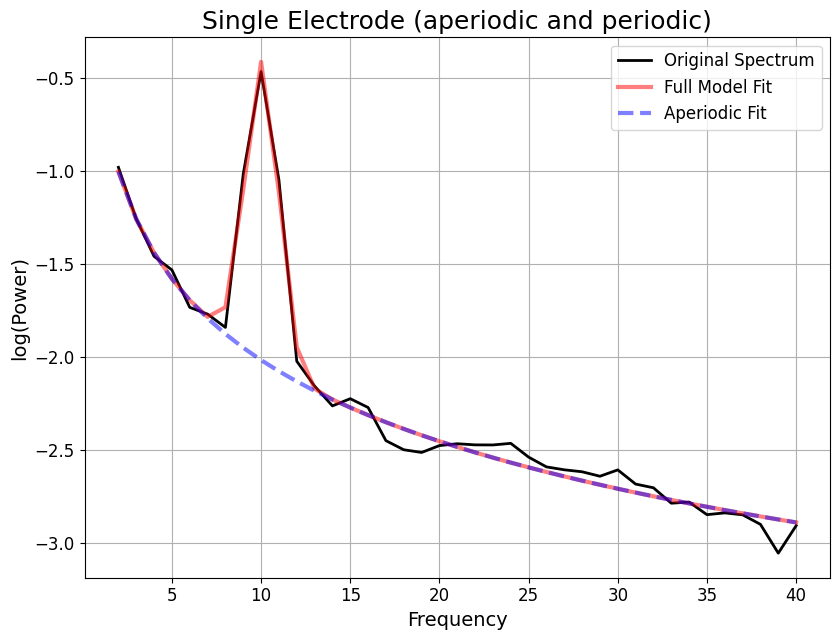

In [11]:
# Initialise Spectral Model
fm = SpectralModel(**spectral_model_params)

# Set frequency range
freq_range = freq_range

# Fitting, plotting and reporting spectral models for each signal
fm.fit(freqs, powers, freq_range)
fm.plot(title = "Single Electrode (aperiodic and periodic)")